<a href="https://colab.research.google.com/github/nyaamikeneko/Qwen_sft_LLM2025/blob/main/create_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd

dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512_v4",
    "u-10bei/structured_data_with_cot_dataset_512_v5",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

all_datasets = []

for name in dataset_names:
    print(f"Loading: {name}")
    # 通常、これらのデータセットは 'train' スプリットにデータがあります
    ds = load_dataset(name, split="train")
    print(f" - Rows: {len(ds)}")
    print(f" - Columns: {ds.column_names}")
    all_datasets.append(ds)

Loading: u-10bei/structured_data_with_cot_dataset_512_v2


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3933 [00:00<?, ? examples/s]

 - Rows: 3933
 - Columns: ['messages', 'metadata']
Loading: u-10bei/structured_data_with_cot_dataset_512_v4


...

 - Rows: 2500
 - Columns: ['messages', 'metadata']
Loading: u-10bei/structured_data_with_cot_dataset


README.md:   0%|          | 0.00/546 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/800k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2500 [00:00<?, ? examples/s]

 - Rows: 2500
 - Columns: ['messages', 'metadata']


In [ ]:
import pandas as pd

for name, ds in zip(dataset_names, all_datasets):
    print(f"Dataset: {name}")
    # Use .select() to get a small subset (2 examples) and convert to pandas for display
    df_sample = ds.select(range(2)).to_pandas()
    display(df_sample)

    # Explicitly print the messages content to check the internal structure
    print(f"Messages structure examples:")
    for i, row in df_sample.iterrows():
        print(f"--- Example {i+1} ---")
        for msg in row['messages']:
            print(msg)
    print("=" * 80)

Dataset: u-10bei/structured_data_with_cot_dataset_512_v2


,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'toml', 'complexity': 'medium', 'sc..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'csv', 'complexity': 'complex', 'sc..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in TOML format. Think step-by-step, then generate syntactically perfect TOML.'}
{'role': 'user', 'content': 'Transform this CSV data into TOML format:\nassessment_id,code,course_id,credits,date,grade,grading_final,grading_homework,grading_midterm,instructor,percentage,schedule,scores,student_id,term,title,total_score,type\r\nASMT-554535,,CRS-9992,,2026-01-03,B,,,,,63.99,,"[{""question"": 1, ""points_earned"": 9, ""points_possible"": 10}, {""question"": 2, ""points_earned"": 6, ""po",STU-693793,,,86,exam\r\n,TNY218,CRS-7794,4,,,40,30,30,Kara Bennett,,"[{""week"": 1, ""topic"": ""present""}, {""week"": 2, ""topic"": ""arrive""}, {""week"": 3, ""topic"": ""school""}, {""",,,Spring 2023,Monitored mobile analyzer 101,,\r\n,ZDW419,CRS-8967,3,,,40,30,30,Cheryl Downs,,"[{""week"": 1, ""topic"": ""form""}, {""week"": 2, ""topic"": ""important""}, {""week"": 3, ""topic"": ""enter""}, {""w",,,Spring 20

,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'xml', 'complexity': 'complex', 'sc..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'yaml', 'complexity': 'simple', 'sc..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in XML format. Analyze the data structure and generate syntactically perfect XML.'}
{'role': 'user', 'content': 'Convert the following TOML to XML:\ntxn = "e7d866e4-e217-4769-af91-6b199ac6c611"\namount = 92.38\nstatus = "completed"\n[[audit_log]]\naction = "created"\nby = "michaelmendez"\ntimestamp = "2016-05-22T16:08:01.325206"\n\n[[audit_log]]\naction = "created"\nby = "whitejoshua"\ntimestamp = "1980-02-24T13:33:42.943177"\n\n[[audit_log]]\naction = "created"\nby = "mollytaylor"\ntimestamp = "1971-07-22T05:19:29.270955"\n\n[meta_info]\ngenerated_at = "2026-01-22T04:03:07.362521"\nversion = "v4.0"\ntags = [ "range", "cover", "use", "stand", "mean",]\n'}
{'role': 'assistant', 'content': 'Approach:\n1. Analyze the input TOML structure: It represents a dictionary with 5 root fields (txn, amount, status...) and a nesting depth of 3.\n2. Identify the target format requirements: XML requires str

...

Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in JSON format. Think step-by-step, then generate syntactically perfect JSON.'}
{'role': 'user', 'content': "Convert the following YAML to JSON:\nreview_id: REV-8045456\nproduct_id: PROD-463913\nuser_id: ba642a1e-c9a9-4bbb-9297-90eddc75d10f\nrating: 4\ntitle: Per responsibility past green trip.\ncontent: 'You woman when. Night collection whole officer along skin.\n\n  Example against need. Likely you good effort. Billion design trouble special tree\n  less tonight.'\ndate: '2026-01-05'\nverified_purchase: true\nhelpful_votes: 48\n"}
{'role': 'assistant', 'content': 'Approach:\n1. Task: Convert customer review from YAML to JSON\n2. Complexity: complex - 8-10 fields, 3-4 levels\n3. Format rules: proper braces/brackets, quoted keys, correct value types\n4. Structure: Organize data logically with appropriate nesting\n5. Transform values to match the target format specifications.\n\nOutput:\n{\n 

,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'toml', 'complexity': 'complex', 's..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'json', 'complexity': 'complex', 's..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in TOML format. Think step-by-step, then generate syntactically perfect TOML.'}
{'role': 'user', 'content': 'I need customer review details in TOML structure.'}
{'role': 'assistant', 'content': 'Approach:\n1. Task: Create customer review in TOML\n2. Complexity: complex - 8-10 fields, 3-4 levels\n3. Format rules: key=value syntax, [sections], proper types\n4. Structure: Organize data logically with appropriate nesting\n5. Populate fields with realistic example data based on the schema.\n\nOutput:\nreview_id = "REV-4098897"\nproduct_id = "PROD-511563"\nuser_id = "1148f45c-7eab-43a5-bbf0-ac83d9e7a966"\nrating = 5\ntitle = "Out week hard serious measure million main."\ncontent = "And including still small soon speech somebody. While leave suddenly new quality soon democratic shoulder. Notice operation doctor anything various fact."\ndate = "2026-01-02"\nverified_purchase = true\nhelpful_votes = 

,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'json', 'complexity': 'medium', 'sc..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'xml', 'complexity': 'simple', 'sch..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in JSON format. Think step-by-step, then generate syntactically perfect JSON.'}
{'role': 'user', 'content': 'Output error log as JSON.'}
{'role': 'assistant', 'content': 'Approach:\n1. Task: Create error log in JSON\n2. Complexity: medium - 5-8 fields, 2-3 levels\n3. Format rules: proper braces/brackets, quoted keys, correct value types\n4. Structure: Organize data logically with appropriate nesting\n\nOutput:\n{\n  "error_id": "ac9070a1-a695-47b8-85b9-9ad6932345ca",\n  "timestamp": "2026-01-04T10:26:54.564900",\n  "level": "ERROR",\n  "service": "exampleService",\n  "message": "Career agreement reduce me land subject information hope.",\n  "stack_trace": [\n    "at learn.py:496",\n    "at Congress.py:245",\n    "at common.py:32",\n    "at society.py:49"\n  ],\n  "context": {\n    "user_id": "f389a61a-430d-4144-8eea-3aa08f5a6d04",\n    "request_id": "c60a8a88-81e5-46b1-a8a2-bd1acfcecee4"\n  

step by stepのデータのみ取り出し

In [ ]:
from datasets import load_dataset, concatenate_datasets
import pandas as pd

dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

all_datasets = []

for name in dataset_names:
    print(f"Loading: {name}")
    # 通常、これらのデータセットは 'train' スプリットにデータがあります
    ds = load_dataset(name, split="train")
    print(f" - Rows: {len(ds)}")
    print(f" - Columns: {ds.column_names}")
    all_datasets.append(ds)

Loading: u-10bei/structured_data_with_cot_dataset_512_v2
 - Rows: 3933
 - Columns: ['messages', 'metadata']
Loading: u-10bei/structured_data_with_cot_dataset_512
 - Rows: 3445
 - Columns: ['messages', 'metadata']
Loading: u-10bei/structured_data_with_cot_dataset_v2
 - Rows: 2500
 - Columns: ['messages', 'metadata']
Loading: u-10bei/structured_data_with_cot_dataset
 - Rows: 2500
 - Columns: ['messages', 'metadata']


In [ ]:
import pandas as pd

for name, ds in zip(dataset_names, all_datasets):
    print(f"Dataset: {name}")
    # Use .select() to get a small subset (2 examples) and convert to pandas for display
    df_sample = ds.select(range(2)).to_pandas()
    display(df_sample)

    # Explicitly print the messages content to check the internal structure
    print(f"Messages structure examples:")
    for i, row in df_sample.iterrows():
        print(f"--- Example {i+1} ---")
        for msg in row['messages']:
            print(msg)
    print("=" * 80)

Dataset: u-10bei/structured_data_with_cot_dataset_512_v2


,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'toml', 'complexity': 'medium', 'sc..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'csv', 'complexity': 'complex', 'sc..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in TOML format. Think step-by-step, then generate syntactically perfect TOML.'}
{'role': 'user', 'content': 'Transform this CSV data into TOML format:\nassessment_id,code,course_id,credits,date,grade,grading_final,grading_homework,grading_midterm,instructor,percentage,schedule,scores,student_id,term,title,total_score,type\r\nASMT-554535,,CRS-9992,,2026-01-03,B,,,,,63.99,,"[{""question"": 1, ""points_earned"": 9, ""points_possible"": 10}, {""question"": 2, ""points_earned"": 6, ""po",STU-693793,,,86,exam\r\n,TNY218,CRS-7794,4,,,40,30,30,Kara Bennett,,"[{""week"": 1, ""topic"": ""present""}, {""week"": 2, ""topic"": ""arrive""}, {""week"": 3, ""topic"": ""school""}, {""",,,Spring 2023,Monitored mobile analyzer 101,,\r\n,ZDW419,CRS-8967,3,,,40,30,30,Cheryl Downs,,"[{""week"": 1, ""topic"": ""form""}, {""week"": 2, ""topic"": ""important""}, {""week"": 3, ""topic"": ""enter""}, {""w",,,Spring 20

,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'json', 'complexity': 'complex', 's..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'csv', 'complexity': 'medium', 'sch..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in JSON format. Think step-by-step, then generate syntactically perfect JSON.'}
{'role': 'user', 'content': "Convert the following YAML to JSON:\nreview_id: REV-8045456\nproduct_id: PROD-463913\nuser_id: ba642a1e-c9a9-4bbb-9297-90eddc75d10f\nrating: 4\ntitle: Per responsibility past green trip.\ncontent: 'You woman when. Night collection whole officer along skin.\n\n  Example against need. Likely you good effort. Billion design trouble special tree\n  less tonight.'\ndate: '2026-01-05'\nverified_purchase: true\nhelpful_votes: 48\n"}
{'role': 'assistant', 'content': 'Approach:\n1. Task: Convert customer review from YAML to JSON\n2. Complexity: complex - 8-10 fields, 3-4 levels\n3. Format rules: proper braces/brackets, quoted keys, correct value types\n4. Structure: Organize data logically with appropriate nesting\n5. Transform values to match the target format specifications.\n\nOutput:\n{\n 

,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'toml', 'complexity': 'complex', 's..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'json', 'complexity': 'complex', 's..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in TOML format. Think step-by-step, then generate syntactically perfect TOML.'}
{'role': 'user', 'content': 'I need customer review details in TOML structure.'}
{'role': 'assistant', 'content': 'Approach:\n1. Task: Create customer review in TOML\n2. Complexity: complex - 8-10 fields, 3-4 levels\n3. Format rules: key=value syntax, [sections], proper types\n4. Structure: Organize data logically with appropriate nesting\n5. Populate fields with realistic example data based on the schema.\n\nOutput:\nreview_id = "REV-4098897"\nproduct_id = "PROD-511563"\nuser_id = "1148f45c-7eab-43a5-bbf0-ac83d9e7a966"\nrating = 5\ntitle = "Out week hard serious measure million main."\ncontent = "And including still small soon speech somebody. While leave suddenly new quality soon democratic shoulder. Notice operation doctor anything various fact."\ndate = "2026-01-02"\nverified_purchase = true\nhelpful_votes = 

,messages,metadata
0,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'json', 'complexity': 'medium', 'sc..."
1,"[{'role': 'system', 'content': 'You are an exp...","{'format': 'xml', 'complexity': 'simple', 'sch..."


Messages structure examples:
--- Example 1 ---
{'role': 'system', 'content': 'You are an expert in JSON format. Think step-by-step, then generate syntactically perfect JSON.'}
{'role': 'user', 'content': 'Output error log as JSON.'}
{'role': 'assistant', 'content': 'Approach:\n1. Task: Create error log in JSON\n2. Complexity: medium - 5-8 fields, 2-3 levels\n3. Format rules: proper braces/brackets, quoted keys, correct value types\n4. Structure: Organize data logically with appropriate nesting\n\nOutput:\n{\n  "error_id": "ac9070a1-a695-47b8-85b9-9ad6932345ca",\n  "timestamp": "2026-01-04T10:26:54.564900",\n  "level": "ERROR",\n  "service": "exampleService",\n  "message": "Career agreement reduce me land subject information hope.",\n  "stack_trace": [\n    "at learn.py:496",\n    "at Congress.py:245",\n    "at common.py:32",\n    "at society.py:49"\n  ],\n  "context": {\n    "user_id": "f389a61a-430d-4144-8eea-3aa08f5a6d04",\n    "request_id": "c60a8a88-81e5-46b1-a8a2-bd1acfcecee4"\n  

In [ ]:
from collections import Counter

def verify_datasets(datasets, dataset_names):
    for ds, name in zip(datasets, dataset_names):
        print(f"--- Verification: {name} ---")

        # 1. 列名の確認
        cols = ds.column_names
        print(f"Columns: {cols}")

        # 2. メッセージ構造の検証
        invalid_structure_count = 0
        roles_distribution = Counter()
        content_empty_count = 0

        for row in ds:
            messages = row.get("messages", [])
            if not isinstance(messages, list):
                invalid_structure_count += 1
                continue

            for msg in messages:
                # キーの存在確認
                if "role" not in msg or "content" not in msg:
                    invalid_structure_count += 1
                    continue

                roles_distribution[msg["role"]] += 1

                # コンテンツの空チェック
                if not msg["content"] or len(msg["content"].strip()) == 0:
                    content_empty_count += 1

        print(f"Invalid structures found: {invalid_structure_count}")
        print(f"Empty content found: {content_empty_count}")
        print(f"Roles distribution: {dict(roles_distribution)}")

        # 3. メタデータキーの抽出
        if "metadata" in cols:
            metadata_keys = set()
            # サンプリングしてキーを確認
            sample_size = min(len(ds), 100)
            for i in range(sample_size):
                meta = ds[i]["metadata"]
                if isinstance(meta, dict):
                    metadata_keys.update(meta.keys())
            print(f"Common metadata keys (sample): {metadata_keys}")

        print("\n")

# 検証の実行
verify_datasets(all_datasets, dataset_names)

# 重複確認用（全データを統合した後の確認を想定）
def check_global_duplicates(datasets):
    all_contents = []
    for ds in datasets:
        # ユーザー入力とアシスタント出力を結合してユニーク性を判断
        for row in ds:
            full_text = "".join([m["content"] for m in row["messages"]])
            all_contents.append(hash(full_text))

    total = len(all_contents)
    unique = len(set(all_contents))
    print(f"Total rows: {total}")
    print(f"Unique rows: {unique}")
    print(f"Duplicate rows: {total - unique}")

check_global_duplicates(all_datasets)

--- Verification: u-10bei/structured_data_with_cot_dataset_512_v2 ---
Columns: ['messages', 'metadata']
Invalid structures found: 0
Empty content found: 0
Roles distribution: {'system': 3933, 'user': 3933, 'assistant': 3933}
Common metadata keys (sample): {'estimated_tokens', 'type', 'format', 'complexity', 'schema'}


--- Verification: u-10bei/structured_data_with_cot_dataset_512 ---
Columns: ['messages', 'metadata']
Invalid structures found: 0
Empty content found: 0
Roles distribution: {'system': 3445, 'user': 3445, 'assistant': 3445}
Common metadata keys (sample): {'estimated_tokens', 'type', 'format', 'complexity', 'schema'}


--- Verification: u-10bei/structured_data_with_cot_dataset_v2 ---
Columns: ['messages', 'metadata']
Invalid structures found: 0
Empty content found: 0
Roles distribution: {'system': 2500, 'user': 2500, 'assistant': 2500}
Common metadata keys (sample): {'complexity', 'format', 'schema', 'estimated_tokens'}


--- Verification: u-10bei/structured_data_with_cot_d

=== 1. 重複分析 (Cross-Dataset Overlap) ===
完全に一致する重複データは見つかりませんでした。

=== 2. メタデータ項目の一致確認 ===
Column 'meta_format' coverage:
dataset_source
u-10bei/structured_data_with_cot_dataset           2500
u-10bei/structured_data_with_cot_dataset_512       3445
u-10bei/structured_data_with_cot_dataset_512_v2    3933
u-10bei/structured_data_with_cot_dataset_v2        2500
Name: meta_format, dtype: int64

Column 'meta_complexity' coverage:
dataset_source
u-10bei/structured_data_with_cot_dataset           2500
u-10bei/structured_data_with_cot_dataset_512       3445
u-10bei/structured_data_with_cot_dataset_512_v2    3933
u-10bei/structured_data_with_cot_dataset_v2        2500
Name: meta_complexity, dtype: int64

Column 'meta_schema' coverage:
dataset_source
u-10bei/structured_data_with_cot_dataset           2500
u-10bei/structured_data_with_cot_dataset_512       3445
u-10bei/structured_data_with_cot_dataset_512_v2    3933
u-10bei/structured_data_with_cot_dataset_v2        2500
Name: meta_schema, dtype: 

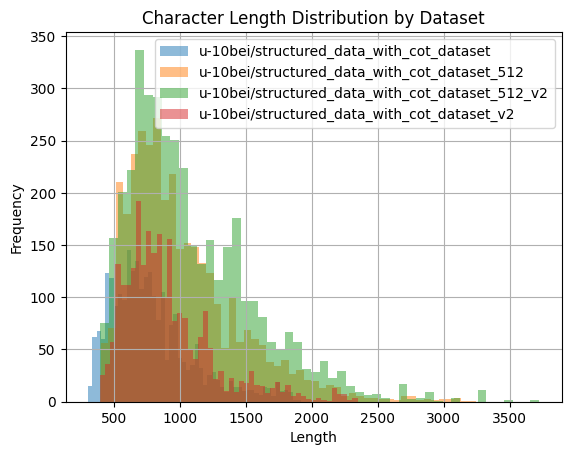

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def deep_dive_analysis(datasets, names):
    df_list = []

    for ds, name in zip(datasets, names):
        df = ds.to_pandas()
        df['dataset_source'] = name

        # メッセージ内容をハッシュ化して重複チェックを容易にする
        # userとassistantの内容を結合してキーにする
        df['content_key'] = df['messages'].apply(
            lambda msgs: "".join([m['content'] for m in msgs if m['role'] in ['user', 'assistant']])
        )

        # 文字数計算
        df['char_length'] = df['content_key'].apply(len)

        # メタデータの展開（統計用）
        if 'metadata' in df.columns:
            meta_df = pd.json_normalize(df['metadata'])
            df = pd.concat([df, meta_df.add_prefix('meta_')], axis=1)

        df_list.append(df)

    # 全データの結合
    combined_df = pd.concat(df_list, ignore_index=True)

    print("=== 1. 重複分析 (Cross-Dataset Overlap) ===")
    duplicate_mask = combined_df.duplicated(subset=['content_key'], keep=False)
    duplicate_df = combined_df[duplicate_mask]

    if not duplicate_df.empty:
        print(f"全体数: {len(combined_df)}")
        print(f"重複行数: {len(duplicate_df)}")
        print("データセットごとの重複内訳:")
        print(duplicate_df['dataset_source'].value_counts())
    else:
        print("完全に一致する重複データは見つかりませんでした。")

    print("\n=== 2. メタデータ項目の一致確認 ===")
    meta_cols = [c for c in combined_df.columns if c.startswith('meta_')]
    for col in meta_cols:
        presence = combined_df.groupby('dataset_source')[col].count()
        print(f"Column '{col}' coverage:\n{presence}\n")

    print("=== 3. テキスト長の統計比較 ===")
    stats = combined_df.groupby('dataset_source')['char_length'].describe()
    print(stats[['mean', 'std', 'min', 'max']])

    # 分布の可視化
    combined_df.groupby('dataset_source')['char_length'].hist(bins=50, alpha=0.5, legend=True)
    plt.title("Character Length Distribution by Dataset")
    plt.xlabel("Length")
    plt.ylabel("Frequency")
    plt.show()

# 実行
deep_dive_analysis(all_datasets, dataset_names)

In [ ]:
import json
from collections import Counter
from datasets import load_dataset

def validate_datasets(dataset_names):
    all_user_contents = []
    dataset_reports = {}

    for name in dataset_names:
        print(f"Loading {name}...")
        ds = load_dataset(name, split="train")

        invalid_format_indices = []
        user_inputs_in_ds = []

        for i, entry in enumerate(ds):
            messages = entry["messages"]

            # 1. 形式の検証（assistantにApproachとOutputが含まれるか）
            assistant_content = ""
            user_content = ""
            for msg in messages:
                if msg["role"] == "assistant":
                    assistant_content = msg["content"]
                elif msg["role"] == "user":
                    user_content = msg["content"]

            # Approach: と Output: の存在確認
            has_approach = "Approach:" in assistant_content
            has_output = "Output:" in assistant_content

            if not (has_approach and has_output):
                invalid_format_indices.append(i)

            # 2. 重複確認用のデータ収集
            if user_content:
                user_inputs_in_ds.append(user_content)
                all_user_contents.append({
                    "dataset": name,
                    "index": i,
                    "content": user_content
                })

        # データセット内での重複計算
        local_counts = Counter(user_inputs_in_ds)
        local_duplicates = {content: count for content, count in local_counts.items() if count > 1}

        dataset_reports[name] = {
            "total_count": len(ds),
            "invalid_format_count": len(invalid_format_indices),
            "invalid_format_indices": invalid_format_indices,
            "internal_duplicates_count": len(local_duplicates)
        }

    # データ間での重複計算
    global_counts = Counter([item["content"] for item in all_user_contents])
    global_duplicates = {content: count for content, count in global_counts.items() if count > 1}

    return dataset_reports, global_duplicates

# 実行
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

reports, cross_dataset_duplicates = validate_datasets(dataset_names)

# 結果の表示
print("\n=== Validation Report ===")
for name, report in reports.items():
    print(f"\nDataset: {name}")
    print(f"  Total Rows: {report['total_count']}")
    print(f"  Invalid Format (Missing Approach/Output): {report['invalid_format_count']}")
    if report['invalid_format_count'] > 0:
        print(f"    Indices: {report['invalid_format_indices']}")
    print(f"  Internal Duplicates: {report['internal_duplicates_count']}")

print(f"\nTotal Cross-Dataset Duplicates: {len(cross_dataset_duplicates)}")

Loading u-10bei/structured_data_with_cot_dataset_512_v2...
Loading u-10bei/structured_data_with_cot_dataset_512...
Loading u-10bei/structured_data_with_cot_dataset_v2...
Loading u-10bei/structured_data_with_cot_dataset...

=== Validation Report ===

Dataset: u-10bei/structured_data_with_cot_dataset_512_v2
  Total Rows: 3933
  Invalid Format (Missing Approach/Output): 0
  Internal Duplicates: 337

Dataset: u-10bei/structured_data_with_cot_dataset_512
  Total Rows: 3445
  Invalid Format (Missing Approach/Output): 0
  Internal Duplicates: 337

Dataset: u-10bei/structured_data_with_cot_dataset_v2
  Total Rows: 2500
  Invalid Format (Missing Approach/Output): 0
  Internal Duplicates: 421

Dataset: u-10bei/structured_data_with_cot_dataset
  Total Rows: 2500
  Invalid Format (Missing Approach/Output): 0
  Internal Duplicates: 255

Total Cross-Dataset Duplicates: 425


Loading u-10bei/structured_data_with_cot_dataset_512_v2...
Loading u-10bei/structured_data_with_cot_dataset_512...
Loading u-10bei/structured_data_with_cot_dataset_v2...
Loading u-10bei/structured_data_with_cot_dataset...
                                   dataset  total  unique  duplicate  \
0  structured_data_with_cot_dataset_512_v2   3933    1825       2108   
1     structured_data_with_cot_dataset_512   3445    1340       2105   
2      structured_data_with_cot_dataset_v2   2500     425       2075   
3         structured_data_with_cot_dataset   2500     255       2245   

       ratio  
0  53.597763  
1  61.103048  
2  83.000000  
3  89.800000  


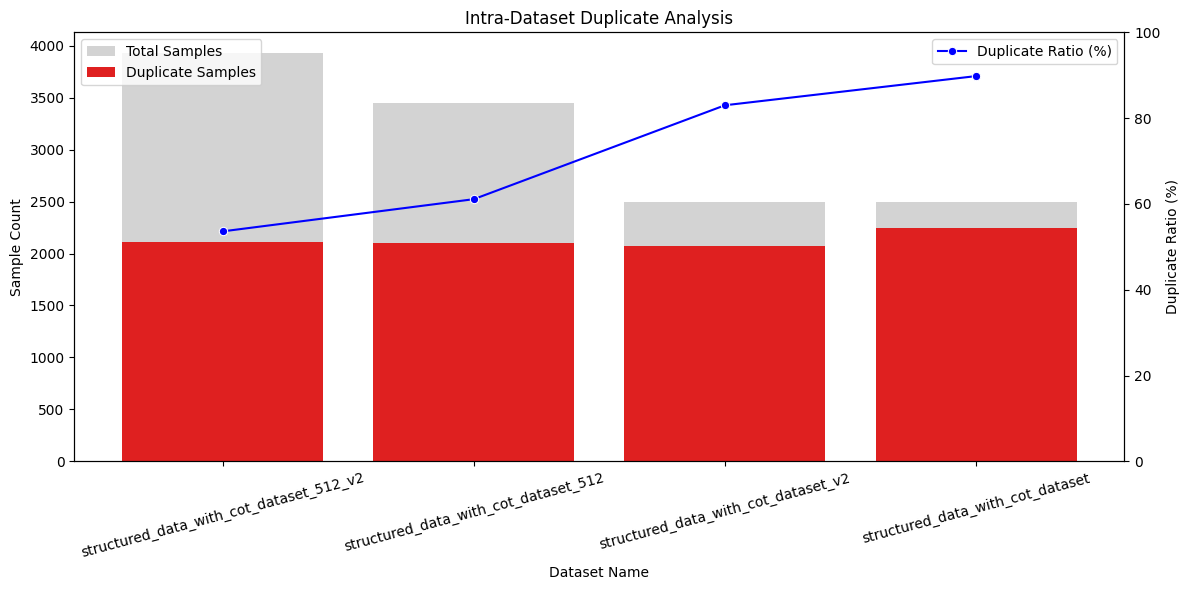

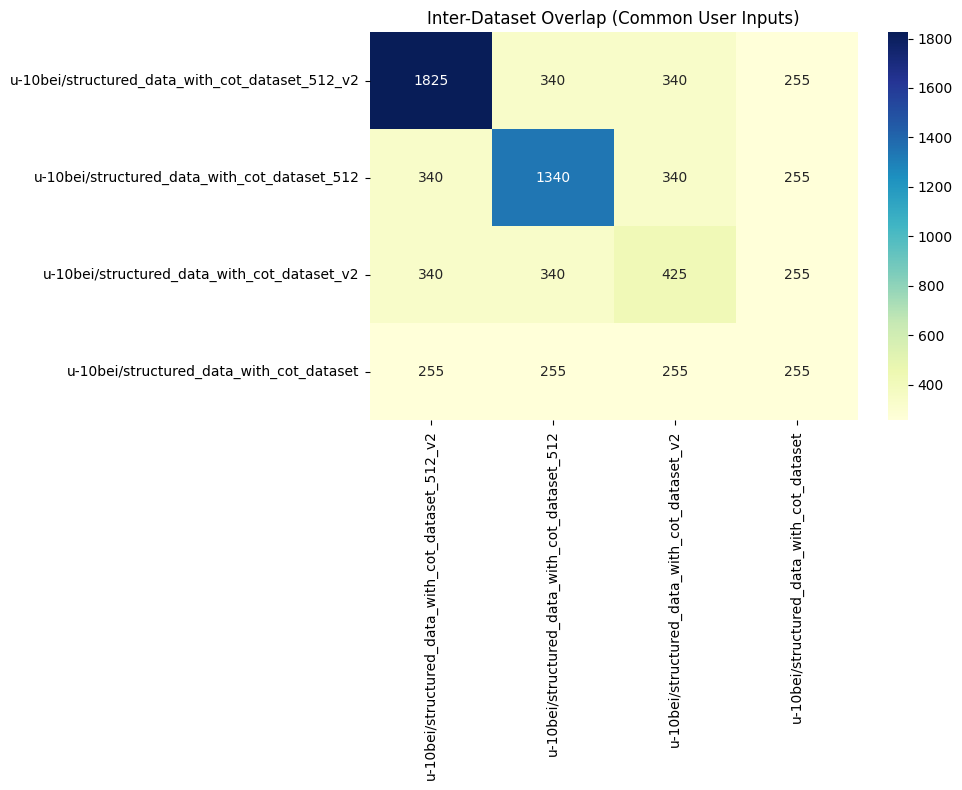

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

def extract_user_content(messages):
    """
    ChatML形式のメッセージリストから、userロールのコンテンツを結合して抽出する。
    """
    user_contents = [m["content"] for m in messages if m["role"] == "user"]
    return "\\n".join(user_contents)

def analyze_datasets(dataset_names):
    stats = []
    dataset_contents = {}

    for name in dataset_names:
        print(f"Loading {name}...")
        # approach有のchatML形式を想定し、trainスプリットを読み込み
        ds = load_dataset(name, split="train")
        df = ds.to_pandas()

        # ユーザー入力を抽出（重複判定のキー）
        df["user_input"] = df["messages"].apply(extract_user_content)

        total_count = len(df)
        unique_count = df["user_input"].nunique()
        duplicate_count = total_count - unique_count
        duplicate_ratio = (duplicate_count / total_count) * 100 if total_count > 0 else 0

        stats.append({
            "dataset": name.split("/")[-1],
            "total": total_count,
            "unique": unique_count,
            "duplicate": duplicate_count,
            "ratio": duplicate_ratio
        })

        dataset_contents[name] = set(df["user_input"].unique())

    stats_df = pd.DataFrame(stats)

    # 可視化処理
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 1. 積み上げ棒グラフ（Total vs Unique）
    sns.barplot(data=stats_df, x="dataset", y="total", color="lightgray", label="Total Samples", ax=ax1)
    sns.barplot(data=stats_df, x="dataset", y="duplicate", color="red", label="Duplicate Samples", ax=ax1)

    ax1.set_ylabel("Sample Count")
    ax1.set_xlabel("Dataset Name")
    ax1.legend(loc="upper left")
    plt.xticks(rotation=15)

    # 2. 重複率の折れ線グラフを右軸に追加
    ax2 = ax1.twinx()
    sns.lineplot(data=stats_df, x="dataset", y="ratio", color="blue", marker="o", label="Duplicate Ratio (%)", ax=ax2)
    ax2.set_ylabel("Duplicate Ratio (%)")
    ax2.set_ylim(0, 100)
    ax2.legend(loc="upper right")

    plt.title("Intra-Dataset Duplicate Analysis")
    plt.tight_layout()
    plt.savefig("intra_dataset_duplicates.png")

    # 3. データセット間の重複（Overlap）のヒートマップ作成
    overlap_matrix = pd.DataFrame(index=dataset_names, columns=dataset_names)
    for name_a in dataset_names:
        for name_b in dataset_names:
            set_a = dataset_contents[name_a]
            set_b = dataset_contents[name_b]
            intersection = len(set_a.intersection(set_b))
            overlap_matrix.loc[name_a, name_b] = intersection

    overlap_matrix = overlap_matrix.astype(int)

    plt.figure(figsize=(10, 8))
    sns.heatmap(overlap_matrix, annot=True, fmt="d", cmap="YlGnBu")
    plt.title("Inter-Dataset Overlap (Common User Inputs)")
    plt.tight_layout()
    plt.savefig("inter_dataset_overlap.png")

    return stats_df, overlap_matrix

# 実行
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

results, overlaps = analyze_datasets(dataset_names)
print(results)

Loading dataset: u-10bei/structured_data_with_cot_dataset_512_v2
Loading dataset: u-10bei/structured_data_with_cot_dataset_512
Loading dataset: u-10bei/structured_data_with_cot_dataset_v2
Loading dataset: u-10bei/structured_data_with_cot_dataset


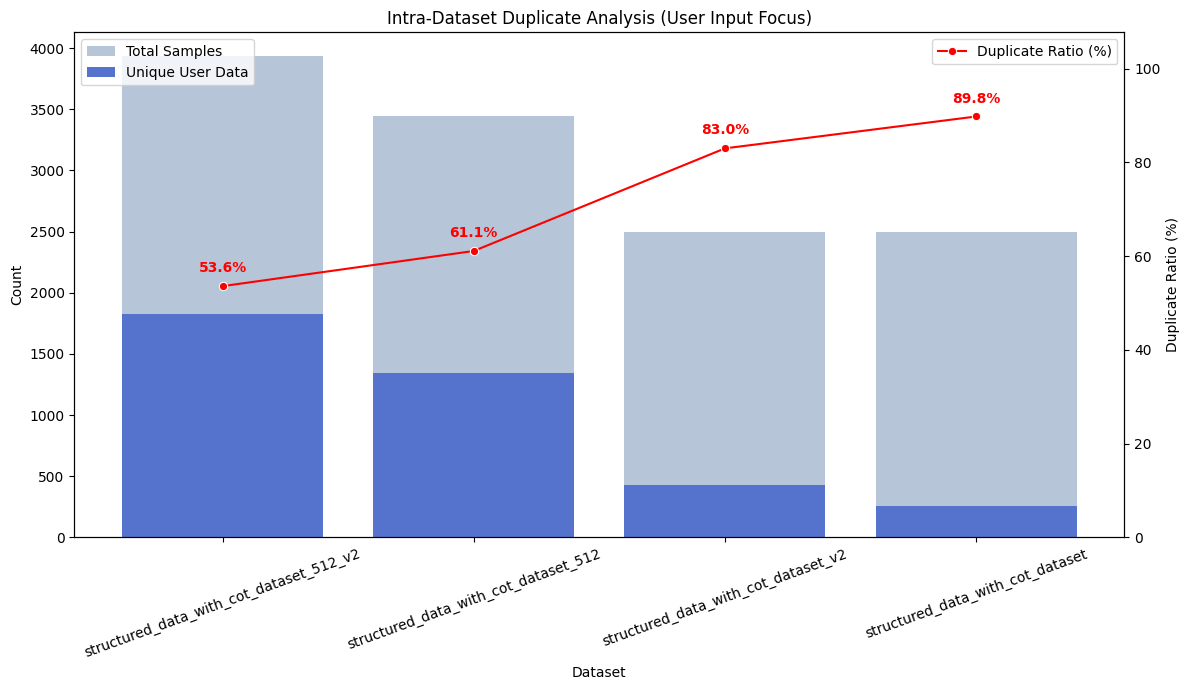

                              dataset_name  total  unique  duplicate  \
0  structured_data_with_cot_dataset_512_v2   3933    1825       2108   
1     structured_data_with_cot_dataset_512   3445    1340       2105   
2      structured_data_with_cot_dataset_v2   2500     425       2075   
3         structured_data_with_cot_dataset   2500     255       2245   

       ratio  
0  53.597763  
1  61.103048  
2  83.000000  
3  89.800000  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

def analyze_and_visualize_duplicates(dataset_names):
    summary_data = []

    for name in dataset_names:
        print(f"Loading dataset: {name}")
        # データセットの読み込み（trainスプリットを想定）
        try:
            ds = load_dataset(name, split="train")
            df = ds.to_pandas()
        except Exception as e:
            print(f"Error loading {name}: {e}")
            continue

        # ChatML形式からuserロールのコンテンツを抽出
        # 複数のuser発言がある場合は結合して一つのユニーク判定キーとする
        def extract_user_input(messages):
            return "\\n".join([m["content"] for m in messages if m["role"] == "user"])

        df["user_input_key"] = df["messages"].apply(extract_user_input)

        # 統計量の算出
        total_count = len(df)
        unique_count = df["user_input_key"].nunique()
        duplicate_count = total_count - unique_count
        duplicate_ratio = (duplicate_count / total_count) * 100 if total_count > 0 else 0

        summary_data.append({
            "dataset_name": name.split("/")[-1],
            "total": total_count,
            "unique": unique_count,
            "duplicate": duplicate_count,
            "ratio": duplicate_ratio
        })

    # データフレームに変換
    results_df = pd.DataFrame(summary_data)

    # 可視化の設定
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # 1. 棒グラフ（全データ数 vs ユニーク数）
    # 積み上げグラフとして表示
    sns.barplot(data=results_df, x="dataset_name", y="total", color="lightsteelblue", label="Total Samples", ax=ax1)
    sns.barplot(data=results_df, x="dataset_name", y="unique", color="royalblue", label="Unique User Data", ax=ax1)

    ax1.set_ylabel("Count")
    ax1.set_xlabel("Dataset")
    ax1.legend(loc="upper left")
    plt.xticks(rotation=20)

    # 2. 折れ線グラフ（重複割合）を右軸に追加
    ax2 = ax1.twinx()
    sns.lineplot(data=results_df, x="dataset_name", y="ratio", color="red", marker="o", label="Duplicate Ratio (%)", ax=ax2)
    ax2.set_ylabel("Duplicate Ratio (%)")
    ax2.set_ylim(0, max(results_df["ratio"].max() * 1.2, 10)) # 最小でも0-10%の範囲を表示
    ax2.legend(loc="upper right")

    # 数値ラベルの追加
    for i, row in results_df.iterrows():
        ax2.annotate(f"{row['ratio']:.1f}%",
                     xy=(i, row['ratio']),
                     xytext=(0, 10),
                     textcoords="offset points",
                     ha="center",
                     color="red",
                     fontweight="bold")

    plt.title("Intra-Dataset Duplicate Analysis (User Input Focus)")
    plt.tight_layout()

    # グラフの保存
    plt.savefig("dataset_duplicate_analysis.png")
    plt.show()

    return results_df

# データセット一覧
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

# 実行
analysis_results = analyze_and_visualize_duplicates(dataset_names)
print(analysis_results)

Loading u-10bei/structured_data_with_cot_dataset_512_v2...
Loading u-10bei/structured_data_with_cot_dataset_512...
Loading u-10bei/structured_data_with_cot_dataset_v2...
Loading u-10bei/structured_data_with_cot_dataset...


/tmp/ipython-input-1393912679.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


------------------------------
Total Samples (Sum of all datasets): 12378
Unique User Inputs: 2910
Redundant Samples: 9468
Overall Redundancy Ratio: 76.49%
------------------------------


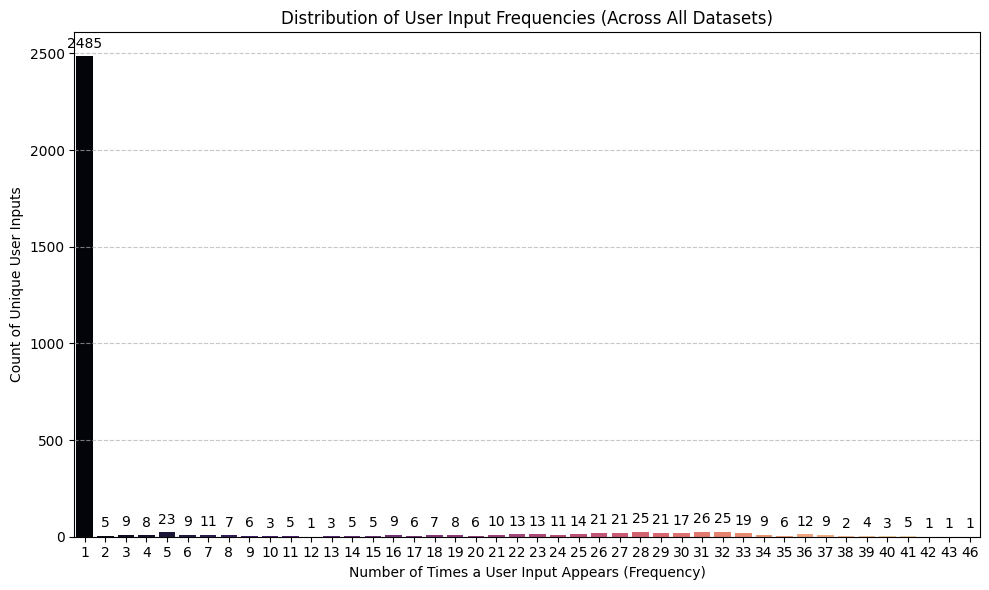

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

def extract_user_content(messages):
    """ChatML形式からuserの発言のみを抽出"""
    return "\\n".join([m["content"] for m in messages if m["role"] == "user"])

def visualize_duplicate_frequency(dataset_names):
    all_user_inputs = []

    # 1. 全データセットからユーザー入力を収集
    for name in dataset_names:
        print(f"Loading {name}...")
        try:
            ds = load_dataset(name, split="train")
            # 各サンプルのメッセージからuser入力を抽出
            user_inputs = [extract_user_content(msg) for msg in ds["messages"]]
            all_user_inputs.extend(user_inputs)
        except Exception as e:
            print(f"Error loading {name}: {e}")

    # 2. 出現回数をカウント
    # counts: { "ユーザー入力内容": 出現回数, ... }
    counts = Counter(all_user_inputs)

    # 3. 頻度分布を作成
    # freq_dist: { 出現回数: その回数出現したユニーク入力数, ... }
    freq_dist = Counter(counts.values())

    # グラフ用データフレーム作成
    freq_df = pd.DataFrame(
        list(freq_dist.items()),
        columns=["Appearances", "Unique_Input_Count"]
    ).sort_values("Appearances")

    # 4. 可視化
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=freq_df,
        x="Appearances",
        y="Unique_Input_Count",
        palette="magma"
    )

    # 棒の上に数値を表示
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

    plt.title("Distribution of User Input Frequencies (Across All Datasets)")
    plt.xlabel("Number of Times a User Input Appears (Frequency)")
    plt.ylabel("Count of Unique User Inputs")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("duplicate_frequency_distribution.png")

    # 統計情報の計算
    total_samples = len(all_user_inputs)
    unique_samples = len(counts)
    redundant_samples = total_samples - unique_samples
    redundancy_ratio = (redundant_samples / total_samples) * 100 if total_samples > 0 else 0

    print("-" * 30)
    print(f"Total Samples (Sum of all datasets): {total_samples}")
    print(f"Unique User Inputs: {unique_samples}")
    print(f"Redundant Samples: {redundant_samples}")
    print(f"Overall Redundancy Ratio: {redundancy_ratio:.2f}%")
    print("-" * 30)

# データセット一覧
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

# 実行
visualize_duplicate_frequency(dataset_names)

Loading u-10bei/structured_data_with_cot_dataset_512_v2...


/tmp/ipython-input-2114913.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


------------------------------
Total Samples (Sum of all datasets): 3933
Unique User Inputs: 1825
Redundant Samples: 2108
Overall Redundancy Ratio: 53.60%
------------------------------


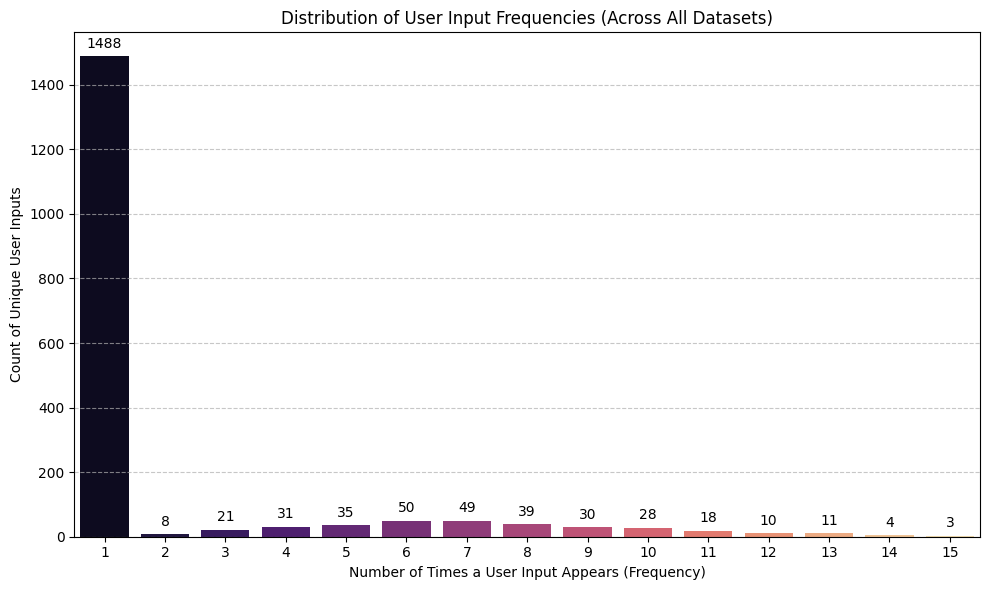

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter

def extract_user_content(messages):
    """ChatML形式からuserの発言のみを抽出"""
    return "\\n".join([m["content"] for m in messages if m["role"] == "user"])

def visualize_duplicate_frequency(dataset_names):
    all_user_inputs = []

    # 1. 全データセットからユーザー入力を収集
    for name in dataset_names:
        print(f"Loading {name}...")
        try:
            ds = load_dataset(name, split="train")
            # 各サンプルのメッセージからuser入力を抽出
            user_inputs = [extract_user_content(msg) for msg in ds["messages"]]
            all_user_inputs.extend(user_inputs)
        except Exception as e:
            print(f"Error loading {name}: {e}")

    # 2. 出現回数をカウント
    # counts: { "ユーザー入力内容": 出現回数, ... }
    counts = Counter(all_user_inputs)

    # 3. 頻度分布を作成
    # freq_dist: { 出現回数: その回数出現したユニーク入力数, ... }
    freq_dist = Counter(counts.values())

    # グラフ用データフレーム作成
    freq_df = pd.DataFrame(
        list(freq_dist.items()),
        columns=["Appearances", "Unique_Input_Count"]
    ).sort_values("Appearances")

    # 4. 可視化
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=freq_df,
        x="Appearances",
        y="Unique_Input_Count",
        palette="magma"
    )

    # 棒の上に数値を表示
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

    plt.title("Distribution of User Input Frequencies (Across All Datasets)")
    plt.xlabel("Number of Times a User Input Appears (Frequency)")
    plt.ylabel("Count of Unique User Inputs")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("duplicate_frequency_distribution.png")

    # 統計情報の計算
    total_samples = len(all_user_inputs)
    unique_samples = len(counts)
    redundant_samples = total_samples - unique_samples
    redundancy_ratio = (redundant_samples / total_samples) * 100 if total_samples > 0 else 0

    print("-" * 30)
    print(f"Total Samples (Sum of all datasets): {total_samples}")
    print(f"Unique User Inputs: {unique_samples}")
    print(f"Redundant Samples: {redundant_samples}")
    print(f"Overall Redundancy Ratio: {redundancy_ratio:.2f}%")
    print("-" * 30)

# データセット一覧
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2"
]

# 実行
visualize_duplicate_frequency(dataset_names)

Loading u-10bei/structured_data_with_cot_dataset_512_v2...
Loading u-10bei/structured_data_with_cot_dataset_512...
Loading u-10bei/structured_data_with_cot_dataset_v2...
Loading u-10bei/structured_data_with_cot_dataset...
Total Unique Users (N): 2910
Allocation per frequency (unique users):
  Frequency 1: 2562 users
  Frequency 2: 67 users
  Frequency 3: 45 users
  Frequency 4: 34 users
  Frequency 5: 27 users
  Frequency 6: 22 users
  Frequency 7: 19 users
  Frequency 8: 17 users
  Frequency 9: 15 users
  Frequency 10: 13 users
  Frequency 11: 12 users
  Frequency 12: 11 users
  Frequency 13: 10 users
  Frequency 14: 10 users
  Frequency 15: 9 users
  Frequency 16: 8 users
  Frequency 17: 8 users
  Frequency 18: 7 users
  Frequency 19: 7 users
  Frequency 20: 7 users
------------------------------
Final Dataset Statistics:
Total samples: 5100
Unique users: 2910


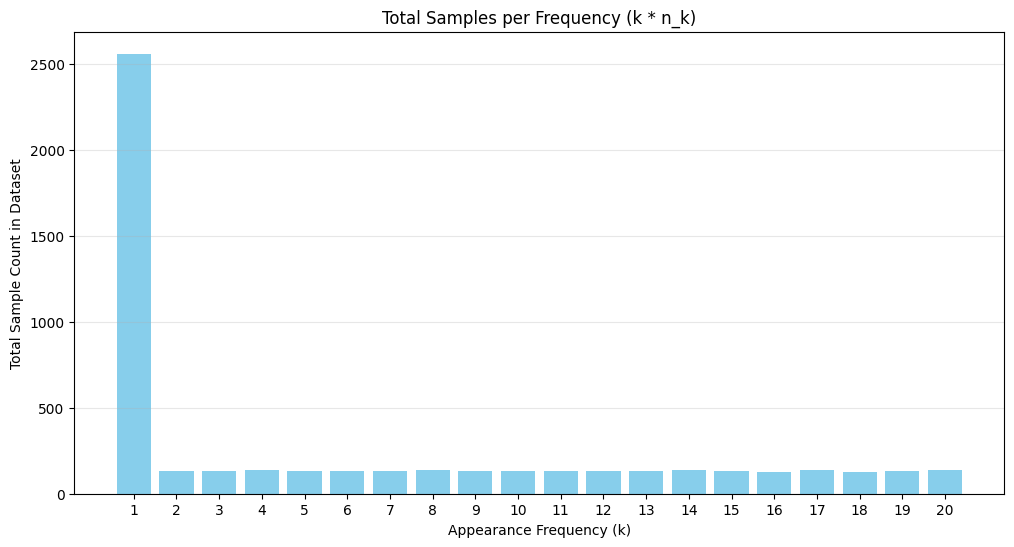

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset, Dataset
import random

def extract_user_content(messages):
    return "\\n".join([m["content"] for m in messages if m["role"] == "user"])

def balance_dataset(dataset_names):
    # 1. 全データの収集とユニーク化
    all_data = []
    seen_prompts = {}

    for name in dataset_names:
        print(f"Loading {name}...")
        ds = load_dataset(name, split="train")
        for item in ds:
            u_input = extract_user_content(item["messages"])
            if u_input not in seen_prompts:
                seen_prompts[u_input] = item

    unique_prompts = list(seen_prompts.keys())
    N = len(unique_prompts)
    print(f"Total Unique Users (N): {N}")

    # 2. 定数 C の計算
    # C = N / (19 + sum(1/k for k in range(2, 21)))
    harmonic_sum = sum(1.0 / k for k in range(2, 21))
    C = N / (19 + harmonic_sum)

    # 3. 各頻度ごとのユニークユーザー割り当て数を計算
    n_k_map = {}
    # 重複スロット (k=2 to 20)
    for k in range(2, 21):
        n_k_map[k] = int(round(C / k))

    # 残りをすべて k=1 (unique) に割り当てて N を維持する
    assigned_dup_unique = sum(n_k_map.values())
    n_k_map[1] = N - assigned_dup_unique

    print("Allocation per frequency (unique users):")
    for k in sorted(n_k_map.keys()):
        print(f"  Frequency {k}: {n_k_map[k]} users")

    # 4. ユーザーを各スロットにランダムに振り分け
    random.shuffle(unique_prompts)

    final_samples = []
    current_idx = 0

    for k in sorted(n_k_map.keys()):
        count = n_k_map[k]
        target_prompts = unique_prompts[current_idx : current_idx + count]
        current_idx += count

        for p in target_prompts:
            original_item = seen_prompts[p]
            # 指定された回数 k だけデータを追加
            for _ in range(k):
                final_samples.append(original_item)

    random.shuffle(final_samples)

    # 5. 結果の検証可視化用データ作成
    final_df = pd.DataFrame([extract_user_content(x["messages"]) for x in final_samples], columns=["user_input"])
    freq_stats = final_df["user_input"].value_counts().value_counts().sort_index()

    print("-" * 30)
    print("Final Dataset Statistics:")
    print(f"Total samples: {len(final_samples)}")
    print(f"Unique users: {final_df['user_input'].nunique()}")

    return Dataset.from_list(final_samples), freq_stats

# データセット一覧
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

balanced_ds, stats = balance_dataset(dataset_names)

# 可視化
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# 各重複回数における「総データ数」が一定（C）になっているか確認
# x軸: 重複回数(k), y軸: k * n_k
x = stats.index
y = stats.index * stats.values

plt.bar(x, y, color='skyblue')
plt.title("Total Samples per Frequency (k * n_k)")
plt.xlabel("Appearance Frequency (k)")
plt.ylabel("Total Sample Count in Dataset")
plt.xticks(range(1, 21))
plt.grid(axis='y', alpha=0.3)
plt.savefig("balanced_distribution.png")
plt.show()

In [ ]:
!pip install huggingface_hub datasets

from huggingface_hub import notebook_login

# 実行すると入力ボックスが表示されるので、コピーしたトークンを貼り付けてください
notebook_login()

In [ ]:
import os

# ユーザー情報とリポジトリ名の設定
username = "lmedz"
repo_name = "integrated_balanced_dataset"
repo_id = f"{username}/{repo_name}"

readme_content = f"""---
language:
- ja
license: apache-2.0
size_categories:
- n<10K
task_categories:
- text-generation
tags:
- chatml
- synthetic
- cot
---

# Dataset Card for {repo_name}

## 概要
このデータセットは、複数のChatML形式のデータセットを統合し、ユーザーの出現頻度分布を調整したものです。

## データ調整の仕様
- 重複なしのユーザー（ユニークユーザー）を100%保持
- 全データのうち、1回のみ出現するユーザーが50%、2回から20回重複するユーザーが50%となるよう調整
- 各重複回数（k=2〜20）における総データ数（$k \times n_k$）が一定になるようにサンプリング

## メタデータ構造（参考）
各レコードは以下の属性に関連付けられています：
- format: toml
- complexity: medium
- schema: student_assessment
- type: conversion
- estimated_tokens: 276

## データの構成
- messages: approach有のchatML形式
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

In [ ]:
from huggingface_hub import HfApi

# 1. データセット本体のアップロード
balanced_ds.push_to_hub(repo_id)

# 2. README.mdのアップロード（リポジトリのトップディレクトリに配置）
api = HfApi()
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=repo_id,
    repo_type="dataset",
)

print(f"Dataset uploaded to: https://huggingface.co/datasets/{repo_id}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  29%|##9       |  528kB / 1.81MB            

Dataset uploaded to: https://huggingface.co/datasets/lmedz/integrated_balanced_dataset


Processing u-10bei/structured_data_with_cot_dataset_512_v2...


Map:   0%|          | 0/3933 [00:00<?, ? examples/s]

Processing u-10bei/structured_data_with_cot_dataset_512...


Map:   0%|          | 0/3445 [00:00<?, ? examples/s]

Processing u-10bei/structured_data_with_cot_dataset_v2...


Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Processing u-10bei/structured_data_with_cot_dataset...


Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

/tmp/ipython-input-995391714.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_dist.index, y=freq_dist.values, palette="viridis")


------------------------------
Total Integrated Samples: 12378


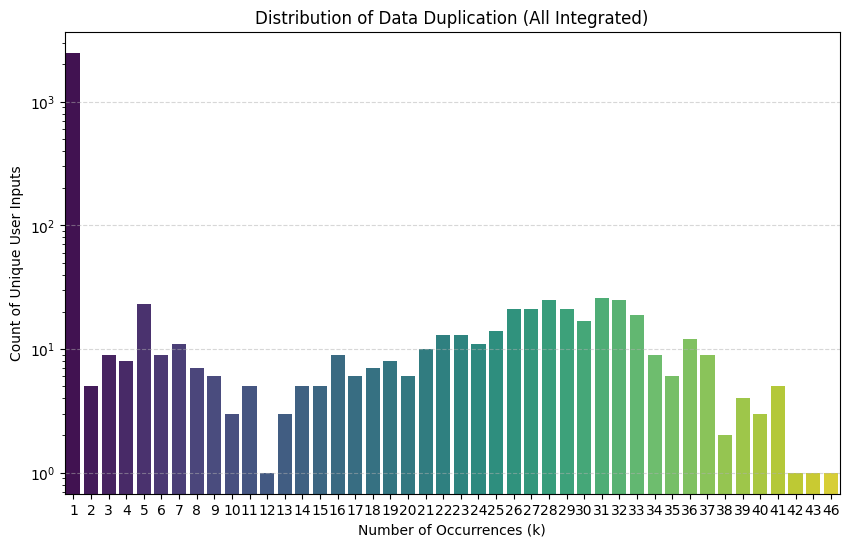

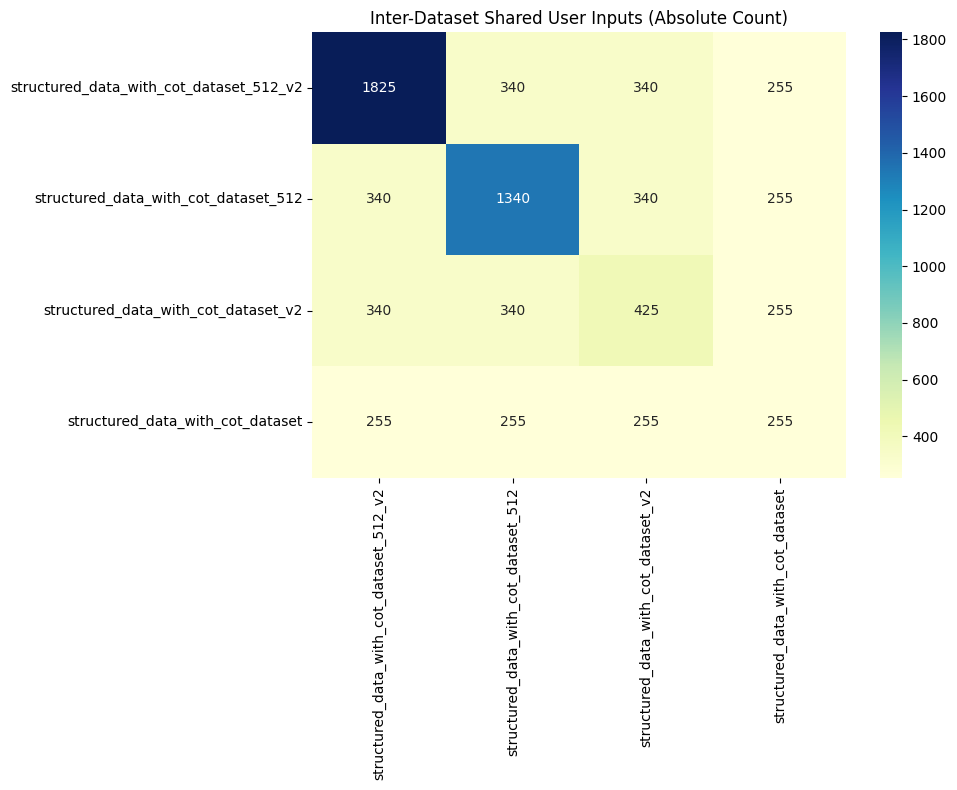

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, concatenate_datasets, Dataset

def normalize_metadata(example):
    """
    メタデータのスキーマを統一する。
    不足しているキー（例: 'type'）がある場合に補完する。
    """
    # メタデータが辞書形式であることを想定
    # もし'metadata'というカラム名であれば、以下のように処理
    if "metadata" in example:
        meta = example["metadata"]
        expected_keys = ["format", "complexity", "schema", "type", "estimated_tokens"]
        for key in expected_keys:
            if key not in meta:
                meta[key] = "unknown"  # 欠損値を補完
        example["metadata"] = meta
    return example

def extract_user_content(messages):
    return "\\n".join([m["content"] for m in messages if m["role"] == "user"])

def integrate_and_visualize(dataset_names):
    all_dfs = []

    for name in dataset_names:
        print(f"Processing {name}...")
        ds = load_dataset(name, split="train")

        # 1. スキーマの正規化（メタデータの欠損補完）
        # map関数を使用して1行ずつ処理
        ds = ds.map(normalize_metadata)

        # 2. Pandasへ変換して管理
        df = ds.to_pandas()
        df["origin_dataset"] = name.split("/")[-1] # 出所を記録
        df["user_input"] = df["messages"].apply(extract_user_content)
        all_dfs.append(df)

    # 3. 全データを削除せず統合
    full_df = pd.concat(all_dfs, ignore_index=True)

    # 4. 重複状況の解析
    # 各ユーザー入力が何回出現するか
    counts = full_df["user_input"].value_counts()
    full_df["occurrence_count"] = full_df["user_input"].map(counts)

    # --- 可視化 1: 重複回数の分布 ---
    plt.figure(figsize=(10, 6))
    freq_dist = counts.value_counts().sort_index()
    sns.barplot(x=freq_dist.index, y=freq_dist.values, palette="viridis")

    plt.title("Distribution of Data Duplication (All Integrated)")
    plt.xlabel("Number of Occurrences (k)")
    plt.ylabel("Count of Unique User Inputs")
    plt.yscale("log") # 数に差がある場合は対数スケールが有効
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.savefig("total_duplication_distribution.png")

    # --- 可視化 2: データセット間での重複割合（ベン図的な行列） ---
    # 各ユーザー入力がどのデータセットに含まれているかをバイナリ行列化
    overlap_df = full_df.groupby("user_input")["origin_dataset"].apply(lambda x: set(x))

    # 行列の初期化
    matrix = pd.DataFrame(0, index=dataset_names, columns=dataset_names)
    dataset_short_names = [n.split("/")[-1] for n in dataset_names]
    matrix.index = dataset_short_names
    matrix.columns = dataset_short_names

    for user_sets in overlap_df:
        sets_list = list(user_sets)
        for i in range(len(sets_list)):
            for j in range(len(sets_list)):
                matrix.loc[sets_list[i], sets_list[j]] += 1

    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="YlGnBu")
    plt.title("Inter-Dataset Shared User Inputs (Absolute Count)")
    plt.tight_layout()
    plt.savefig("dataset_overlap_matrix.png")

    # 5. Hugging Faceアップロード用のDatasetオブジェクト作成
    # user_inputカラムなどは削除して元の形式に戻す
    final_ds = Dataset.from_pandas(full_df.drop(columns=["user_input", "occurrence_count"]))

    return final_ds, full_df

# 実行
dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

integrated_ds, final_df = integrate_and_visualize(dataset_names)

print("-" * 30)
print(f"Total Integrated Samples: {len(final_df)}")

In [ ]:
import pandas as pd
from datasets import load_dataset, Dataset, concatenate_datasets
from huggingface_hub import login, HfApi

# 1. Hugging Faceへログイン
# 事前に取得したWriteトークンを入力してください
login()

dataset_names = [
    "u-10bei/structured_data_with_cot_dataset_512_v2",
    "u-10bei/structured_data_with_cot_dataset_512",
    "u-10bei/structured_data_with_cot_dataset_v2",
    "u-10bei/structured_data_with_cot_dataset"
]

def merge_and_upload(dataset_names, repo_id):
    dfs = []
    all_columns = set()

    # 各データセットの読み込みとカラム抽出
    for name in dataset_names:
        print(f"Loading {name}...")
        ds = load_dataset(name, split="train")
        df = ds.to_pandas()
        dfs.append(df)
        all_columns.update(df.columns.tolist())

    # カラムの正規化（不足カラムの補完と順序の統一）
    # これにより ArrowTypeError を回避します
    sorted_columns = sorted(list(all_columns))
    normalized_dfs = []

    for df in dfs:
        # 存在しないカラムを None で作成し、全 DataFrame で列順を一致させる
        normalized_df = df.reindex(columns=sorted_columns)
        normalized_dfs.append(normalized_df)

    # 全データの統合（削除・重複排除なし）
    merged_df = pd.concat(normalized_dfs, ignore_index=True)

    # Dataset オブジェクトへの変換
    final_ds = Dataset.from_pandas(merged_df)

    # インデックス用カラム (__index_level_0__) が生成される場合があるため削除
    if "__index_level_0__" in final_ds.column_names:
        final_ds = final_ds.remove_columns(["__index_level_0__"])

    # 2. Hugging Face へのアップロード
    print(f"Pushing to Hub: {repo_id}")
    final_ds.push_to_hub(repo_id)

    # 3. README.md の作成とアップロード
    create_readme(repo_id)

def create_readme(repo_id):
    api = HfApi()
    readme_content = f"""---
language:
- ja
license: apache-2.0
task_categories:
- text-generation
tags:
- chatml
- synthetic
- merged
---

# Dataset Card for {repo_id.split('/')[-1]}

## 概要
以下の4つのデータセットを全件統合したデータセットです。
重複排除や削除は行わず、すべてのレコードを保持しています。

## 統合対象データセット
- u-10bei/structured_data_with_cot_dataset_512_v2
- u-10bei/structured_data_with_cot_dataset_512
- u-10bei/structured_data_with_cot_dataset_v2
- u-10bei/structured_data_with_cot_dataset

## スキーマ調整
各データセット間でカラム構成（typeフィールドの有無など）が異なっていたため、全カラムを統合し、欠損しているフィールドには null を補完して正規化を行いました。
"""

    with open("README.md", "w", encoding="utf-8") as f:
        f.write(readme_content)

    api.upload_file(
        path_or_fileobj="README.md",
        path_in_repo="README.md",
        repo_id=repo_id,
        repo_type="dataset",
    )
    print("README.md uploaded successfully.")

# 設定
YOUR_USERNAME = "lmedz"
REPO_NAME = "integrated_full_dataset"
target_repo = f"{YOUR_USERNAME}/{REPO_NAME}"

# 実行
merge_and_upload(dataset_names, target_repo)

Loading u-10bei/structured_data_with_cot_dataset_512_v2...
Loading u-10bei/structured_data_with_cot_dataset_512...
Loading u-10bei/structured_data_with_cot_dataset_v2...
Loading u-10bei/structured_data_with_cot_dataset...
Pushing to Hub: lmedz/integrated_full_dataset


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/13 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  12%|#1        |  528kB / 4.54MB            

README.md uploaded successfully.
